In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

In [2]:
# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/children-born-per-woman.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/children-born-per-woman.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

In [3]:
df.head(3)

,entity,code,year,fertility_rate_hist
0,Afghanistan,AFG,1950,7.248
1,Afghanistan,AFG,1951,7.260
2,Afghanistan,AFG,1952,7.260


In [4]:
df.shape

(19402, 4)

In [5]:
mexico = df[(df["entity"] == "Mexico")]

In [6]:
japon = df[(df["entity"] == "Japan")]

In [7]:
type(mexico)

pandas.DataFrame

In [8]:
mexico.head(10)

,entity,code,year,fertility_rate_hist
11125,Mexico,MEX,1950,6.709
11126,Mexico,MEX,1951,6.727
11127,Mexico,MEX,1952,6.731
11128,Mexico,MEX,1953,6.734
11129,Mexico,MEX,1954,6.745
11130,Mexico,MEX,1955,6.730
11131,Mexico,MEX,1956,6.743
11132,Mexico,MEX,1957,6.752
11133,Mexico,MEX,1958,6.758
11134,Mexico,MEX,1959,6.758


In [9]:
japon.head(10)

,entity,code,year,fertility_rate_hist
8384,Japan,JPN,1947,4.614
8385,Japan,JPN,1948,4.463
8386,Japan,JPN,1949,4.373
8387,Japan,JPN,1950,3.615
8388,Japan,JPN,1951,3.225
8389,Japan,JPN,1952,2.947
8390,Japan,JPN,1953,2.673
8391,Japan,JPN,1954,2.468
8392,Japan,JPN,1955,2.349
8393,Japan,JPN,1956,2.206


In [10]:
anios_mexico = mexico["year"].to_numpy()
tasa_mexico = mexico["fertility_rate_hist"].to_numpy()

In [11]:
anios_japon = japon["year"].to_numpy()
tasa_japon = japon["fertility_rate_hist"].to_numpy()

In [12]:
type(anios_mexico)

numpy.ndarray

In [13]:
type(anios_japon)

numpy.ndarray

In [14]:
promedio_mexico = np.mean(tasa_mexico)
maximo_mexico = np.max(tasa_mexico)

minimo_mexico = np.min(tasa_mexico)
desviacion_mexico = np.std(tasa_mexico)

In [15]:
promedio_japon = np.mean(tasa_japon)
maximo_japon = np.max(tasa_japon)

minimo_japon = np.min(tasa_japon)
desviacion_japon = np.std(tasa_japon)

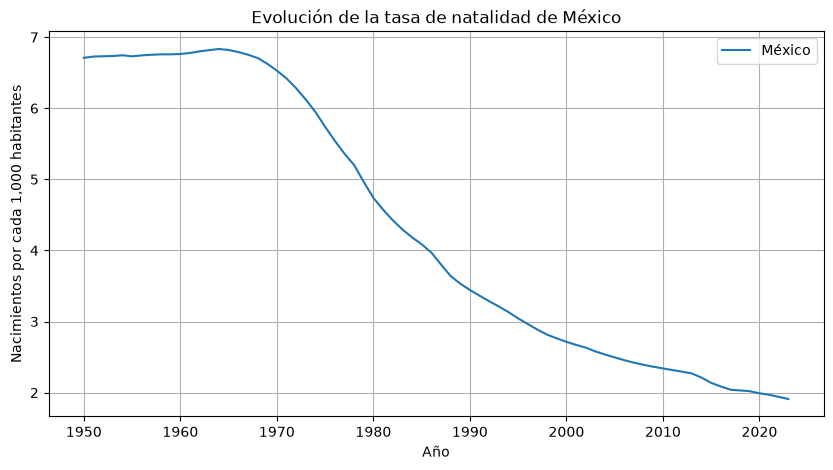

In [16]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_mexico,
    tasa_mexico,
    label = "México"
)

plt.title("Evolución de la tasa de natalidad de México")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

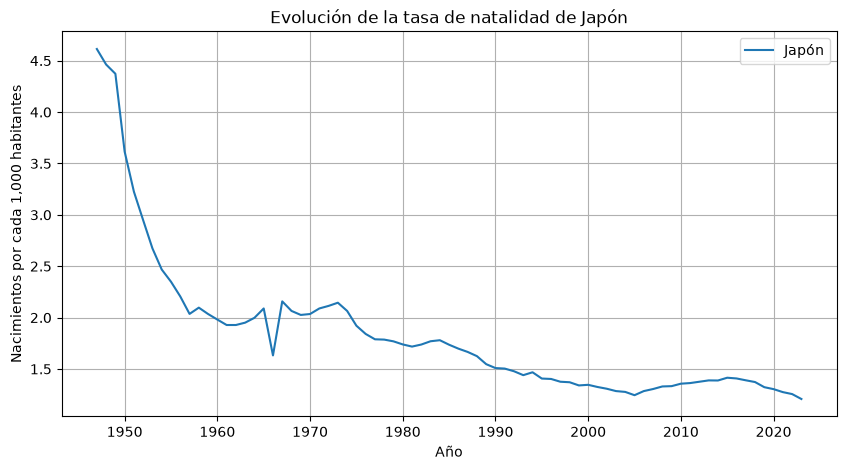

In [17]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_japon,
    tasa_japon,
    label = "Japón"
)

plt.title("Evolución de la tasa de natalidad de Japón")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

In [18]:
diferencia = tasa_mexico - tasa_japon

ValueError: operands could not be broadcast together with shapes (74,) (77,) 

In [19]:
mascara_coincidencia_anios = anios_japon >= anios_mexico.min()

In [20]:
mascara_coincidencia_anios.shape

(77,)

In [21]:
mascara_coincidencia_anios

array([False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [22]:
anios_japon = anios_japon[mascara_coincidencia_anios]


In [23]:
anios_japon.shape

(74,)

In [24]:
tasa_japon = tasa_japon[mascara_coincidencia_anios]

In [25]:
diferencia_mx_jp = tasa_mexico - tasa_japon

In [26]:
diferencia_mx_jp

array([3.094, 3.502, 3.784, 4.061, 4.277, 4.381, 4.537, 4.716, 4.661,
       4.723, 4.782, 4.849, 4.872, 4.866, 4.835, 4.73 , 5.158, 4.595,
       4.642, 4.6  , 4.494, 4.33 , 4.167, 3.976, 3.882, 3.818, 3.702,
       3.572, 3.416, 3.195, 3.   , 2.856, 2.687, 2.526, 2.404, 2.351,
       2.273, 2.137, 2.015, 1.985, 1.935, 1.859, 1.807, 1.771, 1.664,
       1.637, 1.561, 1.51 , 1.444, 1.423, 1.368, 1.346, 1.325, 1.294,
       1.259, 1.25 , 1.171, 1.116, 1.061, 1.031, 0.983, 0.954, 0.918,
       0.88 , 0.823, 0.722, 0.678, 0.651, 0.657, 0.697, 0.686, 0.695,
       0.684, 0.702])

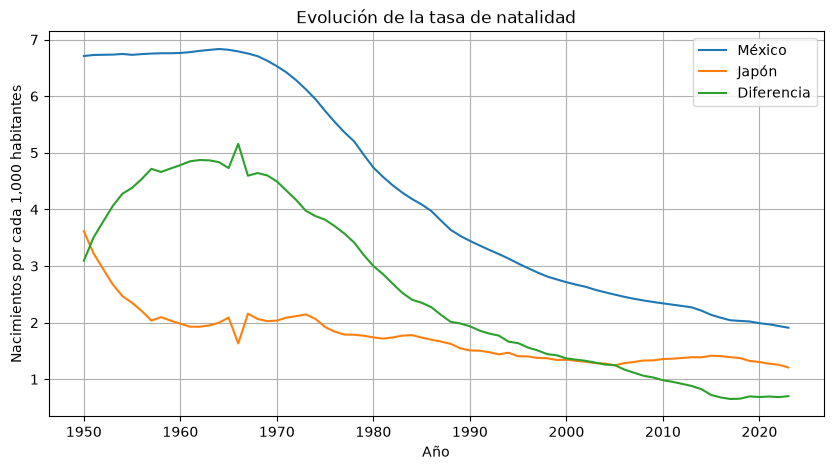

In [27]:
plt.figure(figsize=(10,5))

plt.plot(
    anios_mexico,
    tasa_mexico,
    label = "México"
)

plt.plot(
    anios_japon,
    tasa_japon,
    label = "Japón"
)

plt.plot(
    anios_mexico,
    diferencia_mx_jp,
    label = "Diferencia"
)


plt.title("Evolución de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()


In [28]:
brasil = df[(df["entity"] == "Brazil")]

In [29]:
brasil.head(10)

,entity,code,year,fertility_rate_hist
2371,Brazil,BRA,1950,6.122
2372,Brazil,BRA,1951,6.115
2373,Brazil,BRA,1952,6.102
2374,Brazil,BRA,1953,6.093
2375,Brazil,BRA,1954,6.087
2376,Brazil,BRA,1955,6.084
2377,Brazil,BRA,1956,6.083
2378,Brazil,BRA,1957,6.084
2379,Brazil,BRA,1958,6.083
2380,Brazil,BRA,1959,6.077


In [30]:
anios_brasil = brasil["year"].to_numpy()
tasa_brasil = brasil["fertility_rate_hist"].to_numpy()

In [31]:
promedio_brasil = np.mean(tasa_brasil)
maximo_brasil = np.max(tasa_brasil)

minimo_brasil = np.min(tasa_brasil)
desviacion_brasil = np.std(tasa_brasil)

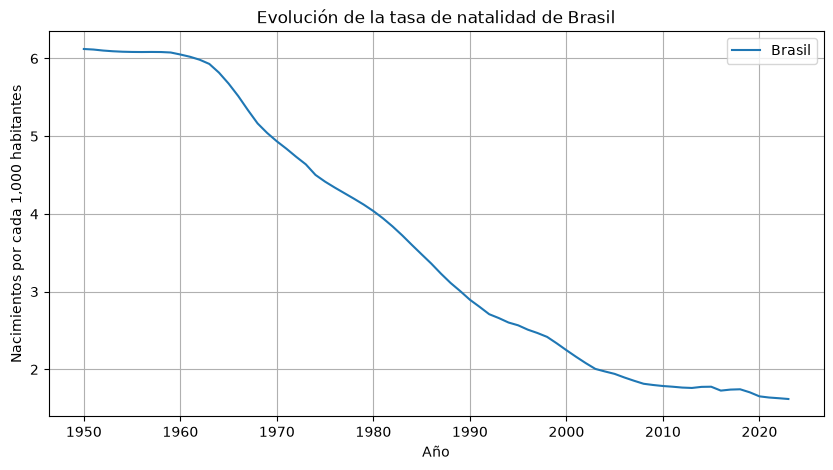

In [32]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_brasil,
    tasa_brasil,
    label = "Brasil"
)

plt.title("Evolución de la tasa de natalidad de Brasil")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

In [33]:
diferencia_mx_br = tasa_mexico - tasa_brasil

In [34]:
diferencia_mx_br

array([0.587, 0.612, 0.629, 0.641, 0.658, 0.646, 0.66 , 0.668, 0.675,
       0.681, 0.712, 0.755, 0.816, 0.887, 1.015, 1.142, 1.274, 1.417,
       1.542, 1.585, 1.595, 1.581, 1.546, 1.483, 1.445, 1.324, 1.204,
       1.094, 1.007, 0.844, 0.702, 0.631, 0.587, 0.573, 0.584, 0.607,
       0.61 , 0.571, 0.528, 0.525, 0.548, 0.558, 0.575, 0.551, 0.529,
       0.477, 0.453, 0.418, 0.397, 0.428, 0.467, 0.509, 0.552, 0.573,
       0.563, 0.553, 0.56 , 0.567, 0.576, 0.565, 0.554, 0.54 , 0.528,
       0.508, 0.436, 0.36 , 0.359, 0.301, 0.286, 0.315, 0.337, 0.332,
       0.311, 0.291])

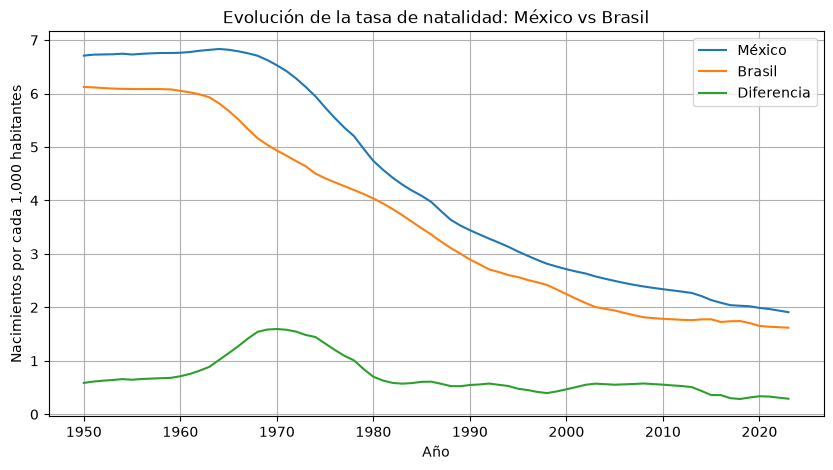

In [35]:
plt.figure(figsize=(10,5))

plt.plot(
    anios_mexico,
    tasa_mexico,
    label = "México"
)

plt.plot(
    anios_brasil,
    tasa_brasil,
    label = "Brasil"
)

plt.plot(
    anios_mexico,
    diferencia_mx_br,
    label = "Diferencia"
)

plt.title("Evolución de la tasa de natalidad: México vs Brasil")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()